# Continuous Market Making with SAC (Colab)

This notebook implements a continuous-action market making experiment using Stable-Baselines3 SAC.

## What this notebook changes
- Continuous inventory in [-1, 1]
- Continuous action space with:
  - delta_bid (bid half-spread)
  - delta_ask (ask half-spread)
  - size_bid (bid quote size)
  - size_ask (ask quote size)
- State space: (inventory, price_deviation, volatility)

## Modeling choices
- Fill logic, adverse selection, OU volatility, reward decomposition, and terminal penalty follow the same structure as the existing DQN implementation.
- SAC is used from Stable-Baselines3 (library implementation; no custom actor/critic/replay code).

## Colab note
- This notebook is fully Colab-compatible.
- SB3 SAC is PyTorch-based and usually runs on CPU/GPU. TPU runtime in Colab is not the standard path for SB3.


In [1]:
# Colab setup
# If running locally, you can skip this cell if packages are already installed.
%pip -q install -U gymnasium stable-baselines3[extra] tensorboard matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 110.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 21.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires tensorboard~=2.19.0, but you have tensorboard 2.20.0 which is incompatible.


In [2]:
import os
import math
import random
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gymnasium as gym
from gymnasium import spaces

import torch

from stable_baselines3 import SAC
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor
from stable_baselines3.common.callbacks import EvalCallback

sns.set_theme(style="whitegrid")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if os.getenv("COLAB_TPU_ADDR"):
    print("TPU runtime detected. SB3 SAC is not natively TPU-accelerated; training may fall back to CPU/GPU behavior.")

torch: 2.10.0+cu128
cuda available: True


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [3]:
@dataclass
class ContinuousMarketParams:
    # Price dynamics
    initial_price: float = 100.0
    sigma_base: float = 0.2

    # OU volatility dynamics
    vol_mean_reversion: float = 0.15
    vol_long_run_mean: float = 1.0
    vol_of_vol: float = 0.2
    vol_floor: float = 0.1

    # Order arrivals: lambda(delta) = A * exp(-k * delta)
    arrival_base: float = 0.5
    arrival_decay: float = 1.5

    # Adverse selection
    adverse_selection: float = 0.2

    # Inventory and reward
    inventory_penalty: float = 0.01
    terminal_penalty: float = 1.0
    episode_length: int = 200
    discount: float = 0.99

    # Continuous action bounds
    delta_min: float = 0.1
    delta_max: float = 3.0
    size_min: float = 0.0
    size_max: float = 0.15

    # Observation scaling
    price_scale: float = 10.0

    # Boundary handling
    block_boundary_breaches: bool = True
    boundary_penalty_coeff: float = 0.0

    def fill_probability(self, spread: float) -> float:
        intensity = self.arrival_base * np.exp(-self.arrival_decay * spread)
        return 1.0 - np.exp(-intensity)


params = ContinuousMarketParams()
params

ContinuousMarketParams(initial_price=100.0, sigma_base=0.2, vol_mean_reversion=0.15, vol_long_run_mean=1.0, vol_of_vol=0.2, vol_floor=0.1, arrival_base=0.5, arrival_decay=1.5, adverse_selection=0.2, inventory_penalty=0.01, terminal_penalty=1.0, episode_length=200, discount=0.99, delta_min=0.1, delta_max=3.0, size_min=0.0, size_max=0.15, price_scale=10.0, block_boundary_breaches=True, boundary_penalty_coeff=0.0)

In [4]:
class ContinuousMarketMakingEnv(gym.Env):
    """
    Continuous-state, continuous-action market-making environment.
    State: [inventory, price_dev, vol_norm]
    Action: [delta_bid, delta_ask, size_bid, size_ask]
    """

    metadata = {"render_modes": []}

    def __init__(self, params: ContinuousMarketParams, seed: int = None):
        super().__init__()
        self.params = params
        self.rng = np.random.RandomState(seed)

        self.observation_space = spaces.Box(
            low=np.array([-1.0, -10.0, 0.0], dtype=np.float32),
            high=np.array([1.0, 10.0, 5.0], dtype=np.float32),
            dtype=np.float32,
        )

        self.action_space = spaces.Box(
            low=np.array([
                self.params.delta_min,
                self.params.delta_min,
                self.params.size_min,
                self.params.size_min,
            ], dtype=np.float32),
            high=np.array([
                self.params.delta_max,
                self.params.delta_max,
                self.params.size_max,
                self.params.size_max,
            ], dtype=np.float32),
            dtype=np.float32,
        )

        self.mid_price = self.params.initial_price
        self.inventory = 0.0
        self.cash = 0.0
        self.volatility = self.params.sigma_base
        self.step_count = 0

        self.pnl_history = []
        self.inventory_history = []
        self.spread_history = []
        self.size_history = []

    def _get_obs(self):
        price_dev = (self.mid_price - self.params.initial_price) / self.params.price_scale
        vol_norm = self.volatility / self.params.vol_long_run_mean
        return np.array([self.inventory, price_dev, vol_norm], dtype=np.float32)

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self.rng = np.random.RandomState(seed)

        self.mid_price = self.params.initial_price
        self.inventory = 0.0
        self.volatility = self.params.sigma_base
        self.cash = -self.inventory * self.mid_price
        self.step_count = 0

        self.pnl_history = [0.0]
        self.inventory_history = [self.inventory]
        self.spread_history = []
        self.size_history = []

        return self._get_obs(), {}

    def step(self, action):
        p = self.params

        action = np.asarray(action, dtype=np.float32)
        action = np.clip(action, self.action_space.low, self.action_space.high)
        delta_bid, delta_ask, size_bid, size_ask = action.tolist()

        self.spread_history.append((delta_bid, delta_ask))
        self.size_history.append((size_bid, size_ask))

        p_bid = p.fill_probability(delta_bid)
        p_ask = p.fill_probability(delta_ask)

        bid_fill = self.rng.random() < p_bid
        ask_fill = self.rng.random() < p_ask

        spread_pnl = 0.0
        boundary_penalty = 0.0

        if bid_fill:
            proposed_inv = self.inventory + size_bid
            if p.block_boundary_breaches and proposed_inv > 1.0:
                bid_fill = False
                boundary_penalty += p.boundary_penalty_coeff * (proposed_inv - 1.0)
            else:
                if proposed_inv > 1.0:
                    boundary_penalty += p.boundary_penalty_coeff * (proposed_inv - 1.0)
                fill_size = min(size_bid, 1.0 - self.inventory)
                if fill_size > 0:
                    self.cash -= fill_size * (self.mid_price - delta_bid)
                    self.inventory += fill_size
                    spread_pnl += fill_size * delta_bid

        if ask_fill:
            proposed_inv = self.inventory - size_ask
            if p.block_boundary_breaches and proposed_inv < -1.0:
                ask_fill = False
                boundary_penalty += p.boundary_penalty_coeff * (-1.0 - proposed_inv)
            else:
                if proposed_inv < -1.0:
                    boundary_penalty += p.boundary_penalty_coeff * (-1.0 - proposed_inv)
                fill_size = min(size_ask, self.inventory + 1.0)
                if fill_size > 0:
                    self.cash += fill_size * (self.mid_price + delta_ask)
                    self.inventory -= fill_size
                    spread_pnl += fill_size * delta_ask

        self.inventory = float(np.clip(self.inventory, -1.0, 1.0))

        dv = (
            p.vol_mean_reversion * (p.vol_long_run_mean - self.volatility)
            + p.vol_of_vol * self.rng.randn()
        )
        self.volatility = max(p.vol_floor, self.volatility + dv)

        adverse = p.adverse_selection * (int(ask_fill) - int(bid_fill))
        dp = adverse + self.volatility * self.rng.randn()
        self.mid_price += dp

        inventory_pnl = self.inventory * dp
        penalty = p.inventory_penalty * (self.inventory ** 2)
        reward = spread_pnl + inventory_pnl - penalty - boundary_penalty

        self.step_count += 1
        terminated = self.step_count >= p.episode_length
        truncated = False
        if terminated:
            reward -= p.terminal_penalty * abs(self.inventory)

        mtm = self.cash + self.inventory * self.mid_price
        self.pnl_history.append(mtm)
        self.inventory_history.append(self.inventory)

        info = {
            "spread_pnl": spread_pnl,
            "inventory_pnl": inventory_pnl,
            "penalty": penalty,
            "boundary_penalty": boundary_penalty,
            "mtm_pnl": mtm,
            "bid_fill": int(bid_fill),
            "ask_fill": int(ask_fill),
        }
        return self._get_obs(), float(reward), terminated, truncated, info


def make_env(seed_offset=0):
    def _thunk():
        env = ContinuousMarketMakingEnv(params=params, seed=SEED + seed_offset)
        return Monitor(env)
    return _thunk

In [5]:
# Sanity checks
test_env = ContinuousMarketMakingEnv(params=params, seed=SEED)
obs, _ = test_env.reset()

for _ in range(1000):
    a = test_env.action_space.sample()
    obs, reward, terminated, truncated, info = test_env.step(a)

    assert -1.000001 <= test_env.inventory <= 1.000001, "Inventory out of bounds"
    assert test_env.volatility >= params.vol_floor, "Volatility floor violation"

    if terminated or truncated:
        obs, _ = test_env.reset()

print("Sanity checks passed.")
print("Obs sample:", obs)
print("Action bounds low:", test_env.action_space.low)
print("Action bounds high:", test_env.action_space.high)

Sanity checks passed.
Obs sample: [0.  0.  0.2]
Action bounds low: [0.1 0.1 0.  0. ]
Action bounds high: [3.   3.   0.15 0.15]


### Training setup

In [6]:
# SAC training setup
train_env = DummyVecEnv([make_env(0)])
train_env = VecMonitor(train_env)

eval_env = DummyVecEnv([make_env(10_000)])
eval_env = VecMonitor(eval_env)

log_dir = "./sac_continuous_logs"
os.makedirs(log_dir, exist_ok=True)

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path=os.path.join(log_dir, "best_model"),
    log_path=os.path.join(log_dir, "eval"),
    eval_freq=10_000,
    deterministic=True,
    render=False,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Training device:", device)

model = SAC(
    policy="MlpPolicy",
    env=train_env,
    learning_rate=3e-4,
    buffer_size=200_000,
    learning_starts=10_000,
    batch_size=256,
    tau=0.005,
    gamma=params.discount,
    train_freq=1,
    gradient_steps=1,
    ent_coef="auto",
    verbose=1,
    tensorboard_log=os.path.join(log_dir, "tb"),
    seed=SEED,
    device=device,
)



/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/vec_env/vec_monitor.py:44: UserWarning: The environment is already wrapped with a `Monitor` wrapperbut you are wrapping it with a `VecMonitor` wrapper, the `Monitor` statistics will beoverwritten by the `VecMonitor` ones.
  warnings.warn(


Training device: cuda
Using cuda device


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Choose the model setup

In [7]:
# ===== Option A: Small-budget (fast) =====
TOTAL_TIMESTEPS = 20_000

model = SAC(
    policy="MlpPolicy",
    env=train_env,
    learning_rate=3e-4,
    buffer_size=100_000,
    learning_starts=5_000,
    batch_size=128,
    tau=0.005,
    gamma=params.discount,   # usually 0.99
    train_freq=1,
    gradient_steps=1,
    ent_coef="auto",
    verbose=1,
    tensorboard_log=os.path.join(log_dir, "tb"),
    seed=SEED,
    device=device,
)

Using cuda device


### Train the model

In [8]:
# Train SAC
# For quick smoke tests in Colab, set total_timesteps=50_000.
# For stronger results, increase to 300_000+.
model.policy

model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=eval_callback, progress_bar=True)
model.save(os.path.join(log_dir, "sac_continuous_final"))
print("Training complete and model saved.")

Logging to ./sac_continuous_logs/tb/SAC_1


Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | -0.0658  |
| time/              |          |
|    episodes        | 4        |
|    fps             | 2296     |
|    time_elapsed    | 0        |
|    total_timesteps | 800      |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | -0.553   |
| time/              |          |
|    episodes        | 8        |
|    fps             | 2263     |
|    time_elapsed    | 0        |
|    total_timesteps | 1600     |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | 0.894    |
| time/              |          |
|    episodes        | 12       |
|    fps             | 2195     |
|    time_elapsed    | 1        |
|    total_timesteps | 2400     |
--------------

Eval num_timesteps=10000, episode_reward=2.49 +/- 2.07

...

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | 1.52     |
| time/              |          |
|    episodes        | 52       |
|    fps             | 130      |
|    time_elapsed    | 79       |
|    total_timesteps | 10400    |
| train/             |          |
|    actor_loss      | -26.1    |
|    critic_loss     | 5.15     |
|    ent_coef        | 0.199    |
|    ent_coef_loss   | -10.6    |
|    learning_rate   | 0.0003   |
|    n_updates       | 5399     |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | 1.32     |
| time/              |          |
|    episodes        | 56       |
|    fps             | 123      |
|    time_elapsed    | 90       |
|    total_timesteps | 11200    |
| train/             |          |
|    actor_loss      | -26.1    |
|    critic_loss     | 0.24     |
|    ent_coef 

Eval num_timesteps=20000, episode_reward=2.47 +/- 2.50

Episode length: 200.00 +/- 0.00

---------------------------------
| eval/              |          |
|    mean_ep_length  | 200      |
|    mean_reward     | 2.47     |
| time/              |          |
|    total_timesteps | 20000    |
| train/             |          |
|    actor_loss      | -18.9    |
|    critic_loss     | 0.278    |
|    ent_coef        | 0.018    |
|    ent_coef_loss   | -5.73    |
|    learning_rate   | 0.0003   |
|    n_updates       | 14999    |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | 1.19     |
| time/              |          |
|    episodes        | 100      |
|    fps             | 95       |
|    time_elapsed    | 209      |
|    total_timesteps | 20000    |
---------------------------------


Training complete and model saved.


### Data Consolidation

In [9]:
def evaluate_policy_detailed(model, env_params, n_episodes=500, seed_base=123):
    episode_rewards = []
    episode_pnls = []
    final_inventories = []
    all_inventories = []
    action_records = []
    vol_records = []

    for i in range(n_episodes):
        env = ContinuousMarketMakingEnv(env_params, seed=seed_base + i)
        obs, _ = env.reset()
        done = False
        total_reward = 0.0

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            action_records.append(action)
            vol_records.append(env.volatility)
            all_inventories.append(env.inventory)
            obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward

        episode_rewards.append(total_reward)
        episode_pnls.append(env.pnl_history[-1])
        final_inventories.append(env.inventory)

    rew = np.asarray(episode_rewards, dtype=float)
    pnl = np.asarray(episode_pnls, dtype=float)
    final_inv = np.asarray(final_inventories, dtype=float)
    all_inv = np.asarray(all_inventories, dtype=float)
    actions = np.asarray(action_records, dtype=float)

    return {
        "mean_reward": rew.mean(),
        "std_reward": rew.std(),
        "sharpe": rew.mean() / (rew.std() + 1e-8),
        "mean_pnl": pnl.mean(),
        "std_pnl": pnl.std(),
        "mean_abs_inventory": np.abs(all_inv).mean(),
        "max_abs_inventory": np.abs(all_inv).max(),
        "mean_abs_final_inventory": np.abs(final_inv).mean(),
        "episode_rewards": rew,
        "episode_pnls": pnl,
        "final_inventories": final_inv,
        "actions": actions,
        "all_vols": np.asarray(vol_records, dtype=float),
    }


stats = evaluate_policy_detailed(model, params, n_episodes=500)

print("Mean reward:", round(stats["mean_reward"], 3))
print("Reward std:", round(stats["std_reward"], 3))
print("Sharpe:", round(stats["sharpe"], 3))
print("Mean PnL:", round(stats["mean_pnl"], 3))
print("Mean |inventory|:", round(stats["mean_abs_inventory"], 3))
print("Mean |final inventory|:", round(stats["mean_abs_final_inventory"], 3))

Mean reward: 1.727
Reward std: 4.369
Sharpe: 0.395
Mean PnL: 2.183
Mean |inventory|: 0.255
Mean |final inventory|: 0.292


### Plotting and Analysis

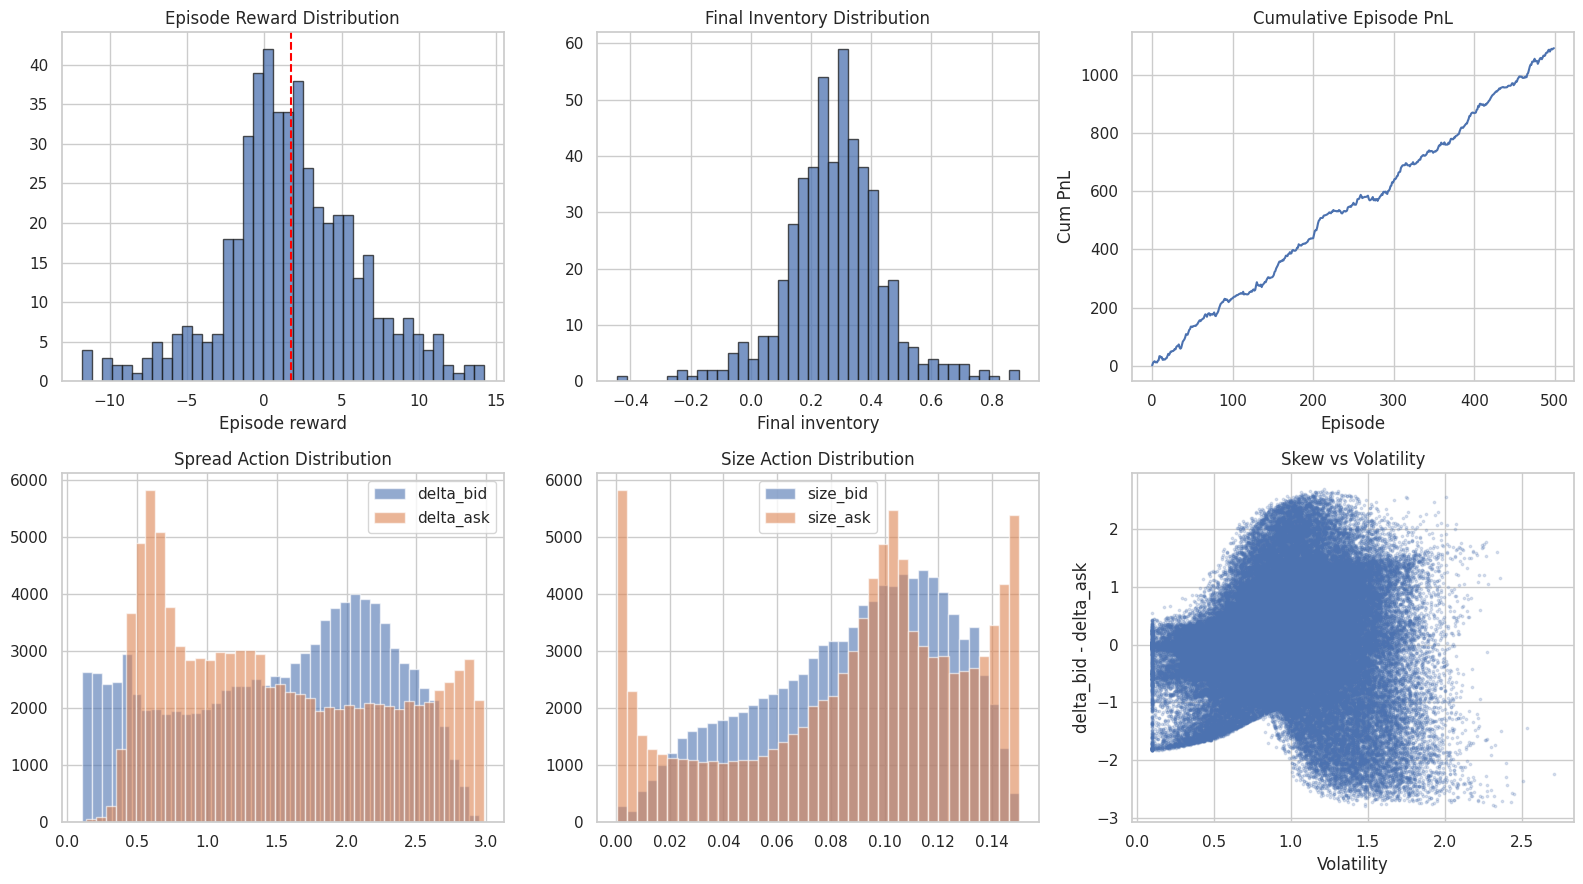

In [10]:
# Evaluation plots
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

axes[0, 0].hist(stats["episode_rewards"], bins=40, edgecolor="k", alpha=0.75)
axes[0, 0].axvline(stats["mean_reward"], color="red", linestyle="--")
axes[0, 0].set_title("Episode Reward Distribution")
axes[0, 0].set_xlabel("Episode reward")

axes[0, 1].hist(stats["final_inventories"], bins=40, edgecolor="k", alpha=0.75)
axes[0, 1].set_title("Final Inventory Distribution")
axes[0, 1].set_xlabel("Final inventory")

cum_pnl = np.cumsum(stats["episode_pnls"])
axes[0, 2].plot(cum_pnl)
axes[0, 2].set_title("Cumulative Episode PnL")
axes[0, 2].set_xlabel("Episode")
axes[0, 2].set_ylabel("Cum PnL")

actions = stats["actions"]
axes[1, 0].hist(actions[:, 0], bins=40, alpha=0.6, label="delta_bid")
axes[1, 0].hist(actions[:, 1], bins=40, alpha=0.6, label="delta_ask")
axes[1, 0].set_title("Spread Action Distribution")
axes[1, 0].legend()

axes[1, 1].hist(actions[:, 2], bins=40, alpha=0.6, label="size_bid")
axes[1, 1].hist(actions[:, 3], bins=40, alpha=0.6, label="size_ask")
axes[1, 1].set_title("Size Action Distribution")
axes[1, 1].legend()

axes[1, 2].scatter(stats["all_vols"], actions[:, 0] - actions[:, 1], s=3, alpha=0.2)
axes[1, 2].set_title("Skew vs Volatility")
axes[1, 2].set_xlabel("Volatility")
axes[1, 2].set_ylabel("delta_bid - delta_ask")

plt.tight_layout()
plt.show()

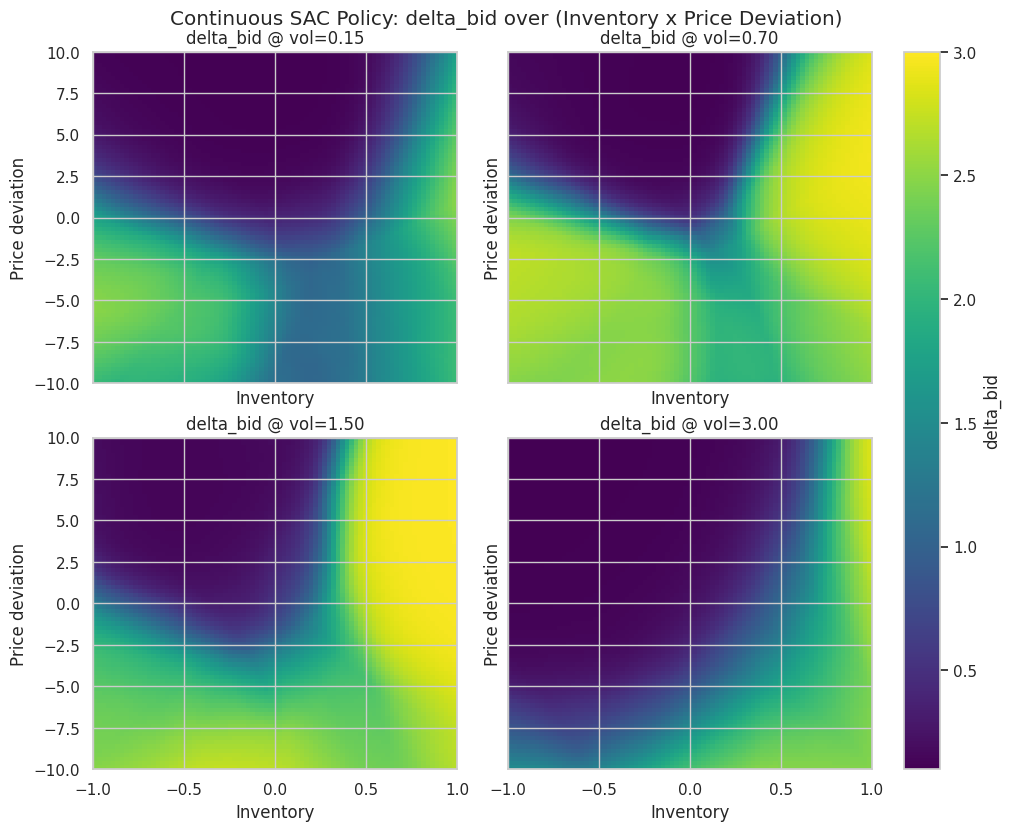

In [15]:
# 2x2 policy heatmaps over (inventory, price_dev) for fixed vol levels

# ---- Config ----
vol_levels = [0.15, 0.7, 1.5, 3]   # choose any 4 vols you want
n_inv = 81
n_price = 81
inv_grid = np.linspace(-1.0, 1.0, n_inv)
price_dev_grid = np.linspace(-10.0, 10.0, n_price)  # raw price deviation axis

# What to plot in color:
# "delta_bid", "delta_ask", "size_bid", "size_ask", "skew"
plot_what = "delta_bid"

def extract_metric(action, kind):
    db, da, sb, sa = action
    if kind == "delta_bid":
        return db
    if kind == "delta_ask":
        return da
    if kind == "size_bid":
        return sb
    if kind == "size_ask":
        return sa
    if kind == "skew":
        return db - da
    raise ValueError(f"Unknown kind: {kind}")

# fixed color range for comparability across subplots
if plot_what in ["delta_bid", "delta_ask"]:
    vmin, vmax = params.delta_min, params.delta_max
elif plot_what in ["size_bid", "size_ask"]:
    vmin, vmax = params.size_min, params.size_max
else:  # skew
    # loose symmetric range; tighten if needed
    vmin, vmax = -(params.delta_max - params.delta_min), (params.delta_max - params.delta_min)

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True, constrained_layout=True)

axes = axes.ravel()

for k, vol in enumerate(vol_levels):
    heat = np.zeros((n_price, n_inv), dtype=np.float32)

    for i, pdev in enumerate(price_dev_grid):
        for j, inv in enumerate(inv_grid):
            # IMPORTANT: env expects normalized price_dev and normalized vol in obs
            obs = np.array(
                [inv, pdev / params.price_scale, vol / params.vol_long_run_mean],
                dtype=np.float32
            )
            action, _ = model.predict(obs, deterministic=True)
            heat[i, j] = extract_metric(action, plot_what)

    ax = axes[k]
    im = ax.imshow(
        heat,
        origin="lower",
        aspect="auto",
        extent=[inv_grid[0], inv_grid[-1], price_dev_grid[0], price_dev_grid[-1]],
        cmap="viridis",
        vmin=vmin,
        vmax=vmax
    )
    ax.set_title(f"{plot_what} @ vol={vol:.2f}")
    ax.set_xlabel("Inventory")
    ax.set_ylabel("Price deviation")

# shared colorbar with a little spacing
cbar = fig.colorbar(
    im,
    ax=axes,
    location="right",
    pad=0.02,       # extra gap between plots and colorbar
    fraction=0.05   # make colorbar a bit narrower
)
cbar.set_label(plot_what)

fig.suptitle(f"Continuous SAC Policy: {plot_what} over (Inventory x Price Deviation)", y=1.02)
plt.show()

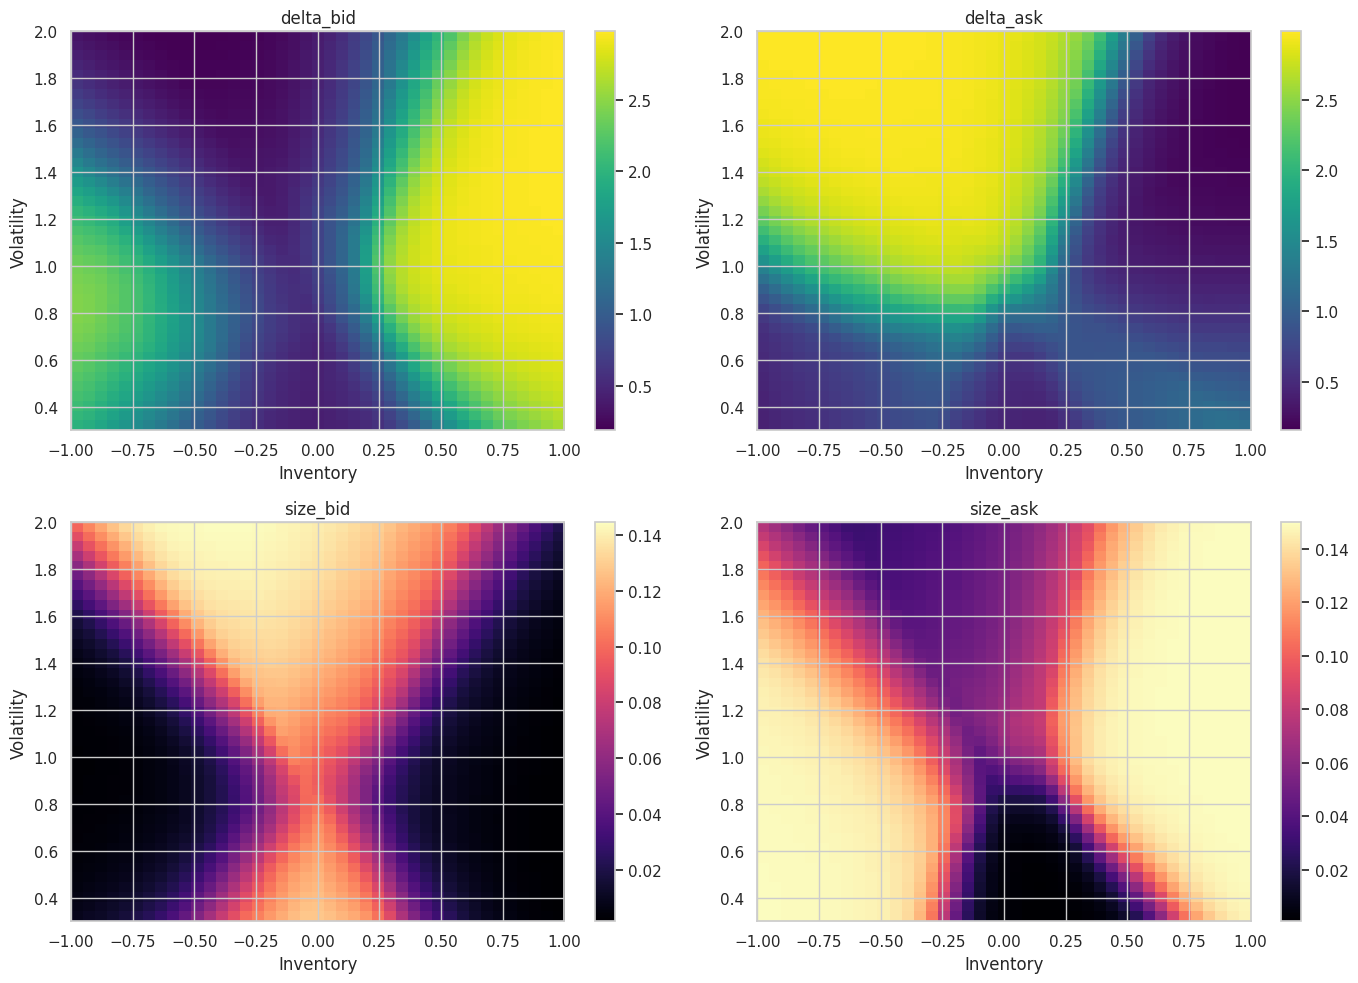

In [11]:
# Policy heatmaps over (inventory, volatility) at fixed price_dev=0
inv_grid = np.linspace(-1.0, 1.0, 41)
vol_grid = np.linspace(0.3, 2.0, 41)

bid_map = np.zeros((len(vol_grid), len(inv_grid)))
ask_map = np.zeros_like(bid_map)
size_bid_map = np.zeros_like(bid_map)
size_ask_map = np.zeros_like(bid_map)

for i, vol in enumerate(vol_grid):
    for j, inv in enumerate(inv_grid):
        obs = np.array([inv, 0.0, vol / params.vol_long_run_mean], dtype=np.float32)
        action, _ = model.predict(obs, deterministic=True)
        bid_map[i, j] = action[0]
        ask_map[i, j] = action[1]
        size_bid_map[i, j] = action[2]
        size_ask_map[i, j] = action[3]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
extent = [inv_grid[0], inv_grid[-1], vol_grid[0], vol_grid[-1]]

im0 = axes[0, 0].imshow(bid_map, origin="lower", aspect="auto", extent=extent, cmap="viridis")
axes[0, 0].set_title("delta_bid")
axes[0, 0].set_xlabel("Inventory")
axes[0, 0].set_ylabel("Volatility")
plt.colorbar(im0, ax=axes[0, 0])

im1 = axes[0, 1].imshow(ask_map, origin="lower", aspect="auto", extent=extent, cmap="viridis")
axes[0, 1].set_title("delta_ask")
axes[0, 1].set_xlabel("Inventory")
axes[0, 1].set_ylabel("Volatility")
plt.colorbar(im1, ax=axes[0, 1])

im2 = axes[1, 0].imshow(size_bid_map, origin="lower", aspect="auto", extent=extent, cmap="magma")
axes[1, 0].set_title("size_bid")
axes[1, 0].set_xlabel("Inventory")
axes[1, 0].set_ylabel("Volatility")
plt.colorbar(im2, ax=axes[1, 0])

im3 = axes[1, 1].imshow(size_ask_map, origin="lower", aspect="auto", extent=extent, cmap="magma")
axes[1, 1].set_title("size_ask")
axes[1, 1].set_xlabel("Inventory")
axes[1, 1].set_ylabel("Volatility")
plt.colorbar(im3, ax=axes[1, 1])

plt.tight_layout()
plt.show()